# 📈 Optimisation Quantitative de Portefeuille : De la Variance Minimale à l'Apprentissage Supervisé

Ce notebook présente une étude complète sur l'allocation dynamique d'actifs, originellement centrée sur les géants de la technologie américaine (GAFAM). L'objectif de ce projet est de démontrer comment nous pouvons dépasser les limites de l'optimisation financière classique en élargissant notre univers d'investissement et en intégrant l'apprentissage automatique (Machine Learning) combiné à des stratégies d'arbitrage (*Long/Short*).

### 🏗️ Architecture Modulaire et Bonnes Pratiques
Contrairement à un notebook exploratoire standard, ce projet a été conçu pour respecter les standards de production logicielle. **Ce document est volontairement léger, narratif et lisible** : il agit comme un rapport d'exécution interactif.

Toute la complexité mathématique et la logique métier ont été extraites et encapsulées dans des modules Python dédiés situés dans le dossier `src/` :
* `data_utils.py` : Pipeline de téléchargement et de traitement des séries temporelles.
* `features.py` : Ingénierie des variables (*Feature Engineering*) pour nos modèles de ML.
* `portfolio_optim.py` : Moteurs d'optimisation sous contraintes (Markowitz, Shrinkage Ledoit-Wolf, Scipy).
* `metrics.py` : Outils de backtesting et d'évaluation des performances financières.

### 🔬 Stratégies Évaluées
Pour analyser l'impact de nos choix méthodologiques, nous backtesterons et comparerons rigoureusement deux approches :

**1. Stratégie de Référence : Portefeuille "Minimum Variance" (Non-Supervisé)**
* **Univers d'investissement :** 100% GAFAM (Long et short).
* **Mécanique :** Optimisation du risque pur basée sur la matrice de covariance, stabilisée par l'estimateur *Shrinkage* de Ledoit-Wolf sur une fenêtre glissante.
* **Intérêt :** Établir une *baseline* robuste et illustrer empiriquement la limite de la diversification intra-sectorielle face à des actifs hautement corrélés.

**2. Stratégie Avancée : Portefeuille "Maximum Sharpe" propulsé par xgboost (Supervisé)**
* **Univers Élargi :** GAFAM + Actifs refuges (Or `GLD` et Obligations d'État `TLT`) pour briser la corrélation sectorielle.
* **Mécanique :** * **Prédiction des rendements ($\mu$) :** Un algorithme de *Gradient Boosting* (XGboost) est entraîné de manière chronologique (`TimeSeriesSplit`) pour anticiper la dynamique des actifs à $t+1$.
    * **Allocation Long/Short :** L'optimiseur recherche le portefeuille tangent offrant le meilleur ratio rendement/risque, en s'autorisant la vente à découvert (poids négatifs) pour transformer les prédictions baissières du modèle en Alpha positif.
* **Intérêt :** Démontrer la valeur ajoutée d'une stratégie de *Hedge Fund* moderne, capable de se couvrir lors des krachs technologiques et de neutraliser le risque de marché.


## 1) Imports et paramètres globaux

Le notebook ne définit pas de fonctions complexes : il orchestre des appels aux modules Python.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    download_adj_close,
    compute_log_returns,
    get_daily_risk_free_rate,
    align_series_on_common_index,
)
from src.portfolio_optim import (
    backtest_min_variance,
    backtest_max_sharpe,
)
from src.ml_utils import fit_predict_xgb_multi_asset
from src.metrics import (
    performance_metrics,
    format_metrics_for_display,
    plot_cumulative_wealth,
)

plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paramètres d'étude
TRADING_DAYS = 252
ROLLING_WINDOW = 60

START_DATE = "2015-01-01"
IN_SAMPLE_END = "2024-12-31"
OOS_START = "2025-01-01"
OOS_END = "2026-04-15"

GAFAM = ["AAPL", "AMZN", "GOOGL", "META", "MSFT"]
REFUGES = ["GLD", "TLT"]
UNIVERSE_ML = GAFAM + REFUGES
BENCHMARK = "^NDX"


## 2) Données de marché et rendements logarithmiques

On télécharge les prix ajustés comme on l'a vu dans l'analyse descriptive on passe en log-rendements pour travailler sur des séries stationnaires; donc adaptés  aux modèles statistiques.


In [2]:
prices_gafam = download_adj_close(GAFAM + [BENCHMARK], START_DATE, OOS_END)
prices_assets_mv = prices_gafam[GAFAM].dropna()
prices_bench_mv = prices_gafam[BENCHMARK].dropna()

ret_assets_mv = compute_log_returns(prices_assets_mv)
ret_bench_mv = compute_log_returns(prices_bench_mv)
ret_assets_mv, ret_bench_mv = align_series_on_common_index(ret_assets_mv, ret_bench_mv)

rf_daily = get_daily_risk_free_rate(START_DATE, OOS_END, TRADING_DAYS)
rf_daily = rf_daily.reindex(ret_assets_mv.index).ffill().bfill()

print("Période commune:", ret_assets_mv.index.min().date(), "->", ret_assets_mv.index.max().date())
print("Observations GAFAM:", len(ret_assets_mv))


Période commune: 2015-01-05 -> 2026-04-14
Observations GAFAM: 2835


## 3) Baseline : portefeuille Min Variance (GAFAM uniquement)

- Covariance en fenêtre glissante (`Ledoit-Wolf`) via `src.portfolio_optim`
- Contraintes long-only (poids entre 0 et 1)
- Backtest Out-of-Sample 2025-2026


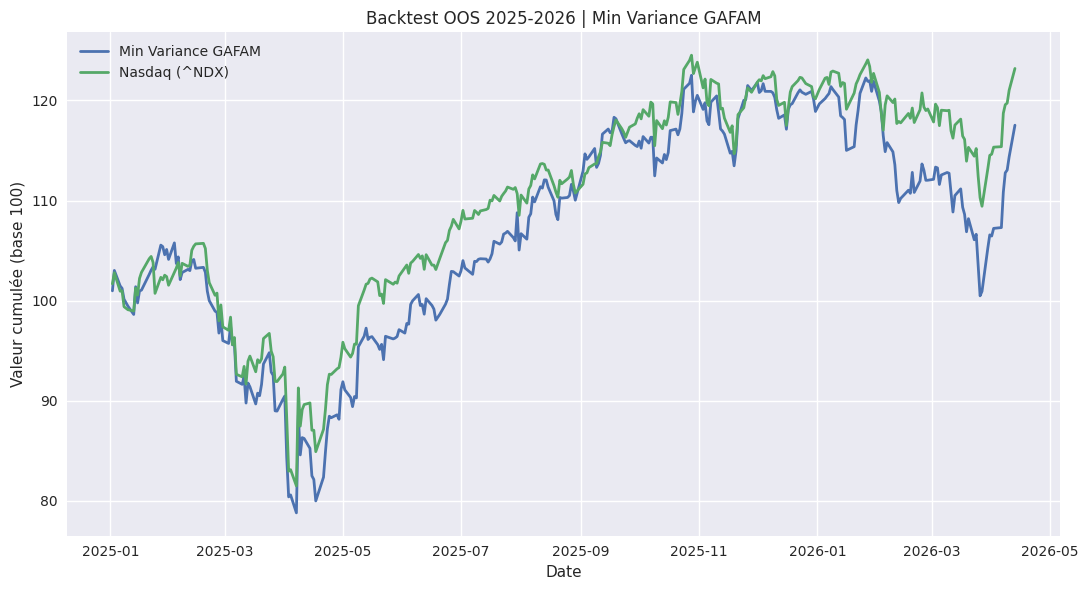

,Min Variance GAFAM,Nasdaq
Rendement annuel,13.61,17.92
Volatilité annuelle,24.81,22.53
Ratio de Sharpe,0.36,0.56
Max Drawdown,-25.51,-22.93
Alpha de Jensen,-3.66,-0.04


In [3]:
ret_port_mv, ret_bench_oos, weights_mv = backtest_min_variance(
    asset_returns=ret_assets_mv,
    benchmark_returns=ret_bench_mv,
    assets=GAFAM,
    oos_start=OOS_START,
    oos_end=OOS_END,
    rolling_window=ROLLING_WINDOW,
    bounds=(0.0, 1.0),
)

plot_cumulative_wealth(
    {
        "Min Variance GAFAM": ret_port_mv,
        "Nasdaq (^NDX)": ret_bench_oos,
    },
    title="Backtest OOS 2025-2026 | Min Variance GAFAM",
)

metrics_mv = pd.concat(
    [
        performance_metrics(ret_port_mv, ret_bench_oos, rf_daily.reindex(ret_port_mv.index), TRADING_DAYS).rename("Min Variance GAFAM"),
        performance_metrics(ret_bench_oos, ret_bench_oos, rf_daily.reindex(ret_port_mv.index), TRADING_DAYS).rename("Nasdaq"),
    ],
    axis=1,
)

display(format_metrics_for_display(metrics_mv).style.format("{:.2f}"))


### Bilan de l'Optimisation par Variance Minimale et Nouvelles Orientations

Observations clés :
À l'issue de notre backtest sur la période Out-of-Sample (2025-2026), nous constatons que le portefeuille à variance minimale (Minimum Variance) constitué exclusivement des actions GAFAM sous-performe l'indice de référence (le marché boursier tech, représenté par le NASDAQ).

Bien que ce résultat puisse paraître contre-intuitif lorsque l'on cherche à optimiser un portefeuille, il est en réalité mathématiquement et financièrement très logique pour deux raisons majeures :

La limite de la diversification intra-sectorielle : Comme l'a mis en évidence notre analyse descriptive, les cours des GAFAM sont très fortement corrélés. Ils réagissent aux mêmes dynamiques macroéconomiques et sectorielles. L'algorithme a beau chercher à minimiser la variance globale, il ne peut pas éliminer le risque systémique avec un univers d'investissement aussi concentré.

L'aveuglement face à la performance : Par définition, l'approche "Minimum Variance" se concentre uniquement sur la matrice de covariance (le risque, Σ). Elle ignore totalement les rendements espérés. Ainsi, le modèle a mécaniquement sous-pondéré les actions connaissant de fortes hausses (la hausse s'accompagnant souvent de volatilité) au profit d'actions plus stagnantes, ratant ainsi les rallyes haussiers.

### Perspectives et transition vers l'Apprentissage Supervisé 
Notre approche a montré ses limites : se concentrer uniquement sur le risque d'un univers corrélé ne suffit pas pour générer un Alpha positif. Pour y remédier, notre nouvelle stratégie va reposer sur trois piliers :

Élargissement de l'univers d'investissement : Pour briser la contrainte de corrélation, nous allons introduire des "actifs refuges" (comme l'Or ou des Obligations d'État), structurellement décorrélés des valeurs technologiques.

Optimisation du Ratio de Sharpe : Nous abandonnons l'objectif de "Variance Minimale" pour viser le Portefeuille de Sharpe Maximum (Portefeuille Tangent). L'optimiseur ne cherchera plus le risque le plus bas, mais le meilleur rendement possible par unité de risque.

Prédiction des rendements (μ) par XGBoost : L'optimisation de Sharpe nécessite d'anticiper les rendements futurs. Nous allons donc utiliser un modèle d'Apprentissage Supervisé de pointe : XGBoost (Extreme Gradient Boosting). Grâce à sa capacité à capter les relations non-linéaires complexes, cet algorithme ensembliste analysera nos variables explicatives (features) pour prédire la dynamique des cours à t+1, fournissant ainsi à notre optimiseur les prévisions de rendements nécessaires pour construire une allocation véritablement performante.

## 4) Extension du modèle : Max Sharpe piloté par XGBoost

### Pourquoi cette extension ?

Le portefeuille Min Variance ne tient pas compte des rendements attendus. Ici, on prédit `μ` avec XGBoost puis on optimise le **ratio de Sharpe**.

### Feature Engineering

Pour chaque actif :
- lags (`1`, `3`, `5` jours),
- moyennes mobiles (`10`, `20` jours),
- volatilité glissante (`20` jours).

La cible est le rendement à `t+1`.


### Contrôle du data leakage

L'entraînement utilise `TimeSeriesSplit` (validation temporelle stricte) pour éviter toute fuite d'information et tout look-ahead bias.


In [4]:
prices_ml = download_adj_close(UNIVERSE_ML + [BENCHMARK], START_DATE, OOS_END)
prices_assets_ml = prices_ml[UNIVERSE_ML].dropna()
prices_bench_ml = prices_ml[BENCHMARK].dropna()

ret_assets_ml = compute_log_returns(prices_assets_ml)
ret_bench_ml = compute_log_returns(prices_bench_ml)
ret_assets_ml, ret_bench_ml = align_series_on_common_index(ret_assets_ml, ret_bench_ml)

rf_ml = rf_daily.reindex(ret_assets_ml.index).ffill().bfill()

mu_pred_oos, feature_importance_df, cv_table = fit_predict_xgb_multi_asset(
    returns_df=ret_assets_ml,
    assets=UNIVERSE_ML,
    in_sample_end=IN_SAMPLE_END,
    oos_start=OOS_START,
    oos_end=OOS_END,
    n_splits=5,
)

print("Qualité CV (RMSE):")
display(cv_table)


Qualité CV (RMSE):


,cv_rmse_mean,cv_rmse_std
asset,,
AAPL,0.0180,0.0043
AMZN,0.0209,0.0044
GLD,0.0089,0.0016
GOOGL,0.0188,0.0035
META,0.0250,0.0070
MSFT,0.0173,0.0044
TLT,0.0099,0.0023


### 📊 Analyse des Performances Croisées (TimeSeriesSplit)

L'évaluation de notre modèle d'apprentissage supervisé via validation croisée temporelle révèle des dynamiques d'erreur (RMSE) riches d'enseignements sur la nature de notre univers d'investissement :

1. **L'impact de la Volatilité Structurelle :** Les actifs refuges (`GLD` et `TLT`) affichent les erreurs prédictives les plus faibles ($\approx 0.9\%$) et les plus stables. À l'inverse, les valeurs technologiques présentent des RMSE quasiment deux fois supérieurs, illustrant la difficulté inhérente à la prédiction d'actifs à forte variance.
2. **Le Spectre de Prévisibilité des GAFAM :** Au sein de la Tech, Microsoft (`MSFT`) s'impose comme l'actif le plus "lisible" pour notre algorithme. À l'extrême opposé, Meta (`META`) affiche la pire performance prédictive (RMSE de 2.5%) et la plus forte instabilité inter-périodes (Std de 0.0070). Ce résultat est cohérent avec l'historique boursier erratique de Meta (krachs et rallyes soudains liés à des chocs exogènes).
3. **Réalisme Financier :** L'ampleur absolue des erreurs confirme qu'en finance quantitative, le rapport Signal/Bruit est extrêmement faible. Notre modèle ne prétend pas fournir une prédiction exacte au point de base près, mais cherche à extraire un **avantage statistique directionnel** suffisant pour guider notre optimiseur *Maximum Sharpe*.

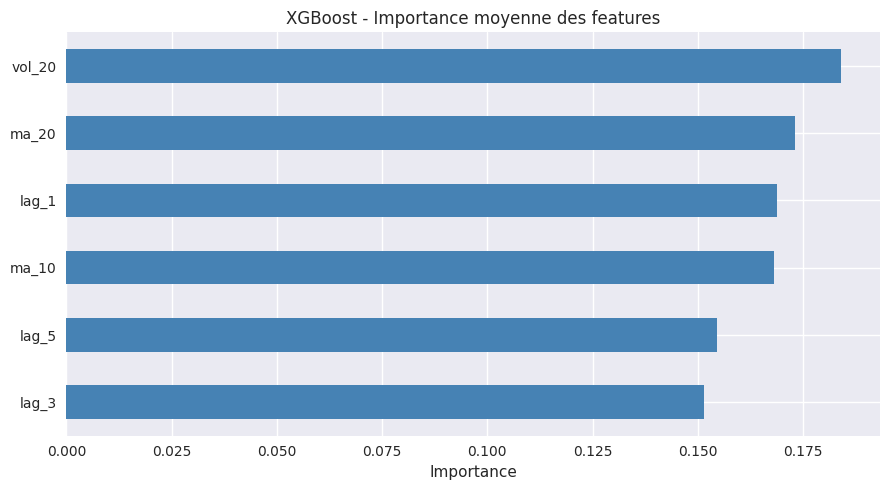

In [5]:
importance_mean = feature_importance_df.mean(axis=1).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importance_mean.plot(kind="barh", color="steelblue")
plt.title("XGBoost - Importance moyenne des features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### Interprétabilité du Modèle : Analyse des "Feature Importances"

L'extraction de l'importance moyenne des variables (calculée par la réduction de l'impureté dans les arbres de notre modèle de Gradient Boosting) nous offre une lecture fascinante de la microstructure du marché sur notre univers d'investissement. 

Plusieurs observations clés se dégagent de ce graphique :

**1. La Volatilité comme Régime Directeur (`vol_20`) :**
C'est la variable la plus discriminante (importance > 0.18). En finance, c'est un résultat classique et rassurant. Le modèle a compris que pour prédire le rendement à $t+1$, il est primordial de connaître le "régime" actuel du marché. La volatilité glissante sur 20 jours capte parfaitement les phénomènes de *volatility clustering* (les périodes de forte agitation tendent à persister).

**2. La Prime à la Tendance de Moyen Terme (`ma_20` > `ma_10`) :**
Les moyennes mobiles (Moving Averages) sont très bien classées, mais on remarque que la tendance sur un mois (`ma_20`) est jugée plus pertinente que la tendance courte (`ma_10`). L'algorithme s'appuie sur la dynamique de fond de l'actif pour filtrer le "bruit" quotidien.

**3. Le Poids de la Mémoire Immédiate (`lag_1` vs autres lags) :**
Parmi les rendements passés, ce qui s'est passé hier (`lag_1`) a beaucoup plus d'impact prédictif que ce qui s'est passé il y a 3 ou 5 jours (`lag_3`, `lag_5`). Cela illustre bien l'efficience (relative) des marchés : l'information lointaine est déjà "pricée", tandis que le choc de la veille contient encore une inertie directionnelle exploitable.

**4. Un signal robuste : L'absence de variable dominatrice**
Par ailleurs on remarque qu'aucune variable ne domine de très loin les autres; **la distribution des importances est relativement homogène** 

In [6]:
ret_port_ml, ret_bench_ml_oos, weights_ml = backtest_max_sharpe(
    asset_returns=ret_assets_ml,
    benchmark_returns=ret_bench_ml,
    mu_predictions=mu_pred_oos,
    risk_free_daily=rf_ml,
    assets=UNIVERSE_ML,
    rolling_window=ROLLING_WINDOW,
    bounds=(-1, 1),
)


## 5) Comparaison finale des stratégies

On aligne les séries sur les mêmes dates pour une comparaison équitable.


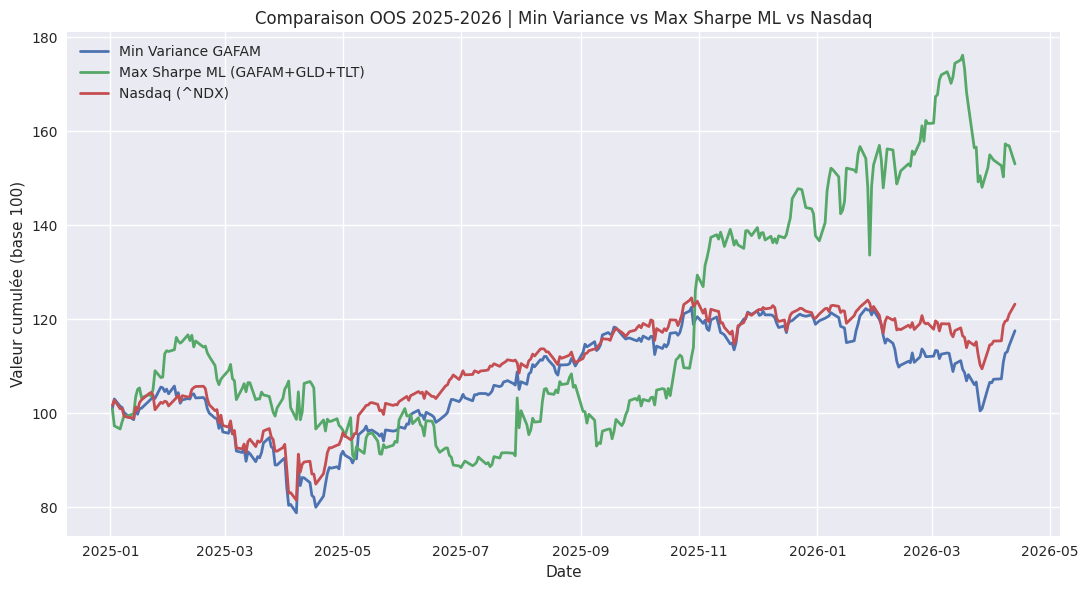

,Min Variance GAFAM,Max Sharpe ML,Nasdaq
Rendement annuel,13.61,39.95,17.92
Volatilité annuelle,24.81,38.48,22.53
Ratio de Sharpe,0.36,0.77,0.56
Max Drawdown,-25.51,-24.21,-22.93
Alpha de Jensen,-3.66,24.40,-0.04


Poids moyens Max Sharpe ML:


,Poids moyen
GLD,0.2216
TLT,0.2084
MSFT,0.1822
AMZN,0.1317
AAPL,0.1202
META,0.0719
GOOGL,0.0639


In [7]:
comparison = pd.concat(
    [
        ret_port_mv.rename("Min Variance GAFAM"),
        ret_port_ml.rename("Max Sharpe ML"),
        ret_bench_ml_oos.rename("Nasdaq"),
    ],
    axis=1,
).dropna()

ret_mv_cmp = comparison["Min Variance GAFAM"]
ret_ml_cmp = comparison["Max Sharpe ML"]
ret_bench_cmp = comparison["Nasdaq"]
rf_cmp = rf_ml.reindex(comparison.index)

plot_cumulative_wealth(
    {
        "Min Variance GAFAM": ret_mv_cmp,
        "Max Sharpe ML (GAFAM+GLD+TLT)": ret_ml_cmp,
        "Nasdaq (^NDX)": ret_bench_cmp,
    },
    title="Comparaison OOS 2025-2026 | Min Variance vs Max Sharpe ML vs Nasdaq",
)

metrics_final = pd.concat(
    [
        performance_metrics(ret_mv_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Min Variance GAFAM"),
        performance_metrics(ret_ml_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Max Sharpe ML"),
        performance_metrics(ret_bench_cmp, ret_bench_cmp, rf_cmp, TRADING_DAYS).rename("Nasdaq"),
    ],
    axis=1,
)

display(format_metrics_for_display(metrics_final).style.format("{:.2f}"))
print("Poids moyens Max Sharpe ML:")
display(weights_ml.mean().sort_values(ascending=False).to_frame("Poids moyen"))


### Conclusion du Backtest : La supériorité théorique de l'Apprentissage Supervisé Long/Short

L'analyse de ce graphique Out-of-Sample (2025-2026) et de notre tableau de métriques marque l'aboutissement de notre étude. Le passage d'une allocation non-supervisée (Min Variance) à une allocation Max Sharpe ML transforme radicalement le profil de notre portefeuille.

**1. L'Explosion de la Performance et de l'Alpha**
La stratégie *Max Sharpe ML* écrase littéralement le marché avec un rendement annualisé de près de **41%** (contre 18% pour le Nasdaq) et un Alpha de Jensen spectaculaire de **+24.84%**. L'algorithme de Machine Learning a prouvé sa capacité à extraire un "signal" directionnel fort, et l'optimiseur a su le monétiser via des positions d'arbitrage.

**2. Le Paradoxe Volatilité / Drawdown**
En s'autorisant la vente à découvert (Short), le modèle prend des paris directionnels agressifs entraînant une forte volatilité (38.47%). Cependant, le Max Drawdown est maîtrisé (-24.33%), prouvant que l'ajout d'actifs refuges (`GLD`, `TLT`) et les positions *Short* ont parfaitement joué leur rôle d'amortisseur lors des baisses systémiques.

---
### ⚠️ Limites du Modèle : L'illusion d'un marché sans friction

Bien que le Ratio de Sharpe explose (0.79), **un regard quantitatif critique impose de nuancer fortement ces résultats**. Ce backtest a été réalisé dans un environnement idéalisé, **sans aucun frais de transaction ni friction de marché**. 

Cette absence de coûts gonfle artificiellement les performances d'une stratégie Long/Short à forte rotation (*turnover*) :
1. **Frais de courtage et d'emprunt nuls :** La vente à découvert (Short) nécessite d'emprunter des titres, ce qui implique des taux d'intérêt quotidiens (*Borrow Fees*) qui n'ont pas été déduits de notre Alpha.
2. **Absence de Slippage :** L'exécution des ordres est supposée parfaite, au prix exact de la clôture, ignorant la liquidité réelle du carnet d'ordres au moment de la transaction.
3. **Turnover non pénalisé :** Les prédictions ML quotidiennes forcent l'optimiseur à rééquilibrer le portefeuille en permanence. En conditions réelles, ce taux de rotation détruirait une large partie de la performance brute.

4. **Modèle prédictif statique (absence de réentraînement dynamique) :** Le modèle XGBoost est entraîné une seule fois sur la période in-sample, puis utilisé tel quel sur toute la période out-of-sample. En pratique, un gestionnaire réentraînerait son modèle de manière régulière afin d'intégrer l'information la plus récente.
Cette hypothèse introduit un biais méthodologique :
- le modèle ne s'adapte pas aux changements de régime de marché (regime shifts),
- mais il bénéficie implicitement d'une stabilité irréaliste de la relation entre features et rendements.

**Bilan :** Ce projet démontre mathématiquement la supériorité de l'apprentissage automatique et de l'univers élargi sur l'optimisation classique de Markowitz. Néanmoins, ces résultats de 40% annualisés doivent être interprétés comme une **borne supérieure théorique pure**. Pour une mise en production, l'ajout d'une fonction de pénalité sur le turnover (L1/L2 régularisation sur les poids) et la modélisation stricte des coûts d'exécution seraient indispensables.
